In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import os
from hubble import hubble_fit
from hubble.hubble_fit import *
from hubble.hubble_utils import *
from hubble.hubble_likelihood import *
from hubble.hubble_plotting import *
from hubble.hubble_model import *
from hubble.hubble_completeness_refactored import *

CPU Num Cores: 6


In [ ]:
import jax_cosmo

In [2]:
from hubble.completeness_mock_catalog import (
    COSMO,
    build_shen_lf,
    mock_m_per_zbin,
    save_mock_catalog,
)

In [3]:
# ----------------------------
# Load Pantheon
# ----------------------------
df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = hubble_fit.load_pantheon_data()


# --------------------------------------------------
# 1. Load AGN sample
# --------------------------------------------------
lc_fitting_results_file = "../data/mar16e_chisq_N1w2000s500t14ch4.h5.pkl"
spectra_fitting_results_file = "../data/results/data/jaxqsofit_mar15c.csv"

df_agn, df_agn_all = load_agn_data(
    lc_fitting_results_file,
    only_load=False,
    fhost_cut=10,
    spectra_fit_csv=[spectra_fitting_results_file],
    correct_sigma_uv_host=False,
    pickled=True,
)

# --------------------------------------------------
# 2. Generate Hopkins mock catalog
# --------------------------------------------------
phi_log10, m_grid, z_bins = build_shen_lf(None)

rng = np.random.default_rng(123)
_, nexp, _, nsel, z_all, m_all, m_2500_all, bin_index = mock_m_per_zbin(
    phi_log10,
    m_grid,
    z_bins,
    area_deg2=5.0,
    alpha_nu=-0.5,
    dalpha_nu=0.3,
    cosmo=COSMO,
    z_res=512,
    m_scatter=0.0,
    kcorr_zref=2.0,
    m_lim=28.0,
    rng=rng,
    return_z=True,
    return_global=True,
    verbose=True,
)

sim_file = "../data/mock_mag_z_hopkins.h5"
save_mock_catalog(sim_file, z_all, m_all, m_2500_all, m_limit=28.0)
print(f"Saved mock catalog: {sim_file}")
print(f"Generated {len(z_all)} mock sources before final save cut.")

# --------------------------------------------------
# 3. Build completeness map from that mock
# --------------------------------------------------
completeness2d, mag_centers, z_centers, dm, dz, sigma_mag = get_completeness_function_2d(
    df_agn,
    sim_file=sim_file,
    n_mag_bins=30,
    n_z_bins=40,
    smooth_counts=True,
    plot=True,
    fill_along_mag=False,
    fill_along_z=False,
)

print("Completeness sim file:", sim_file)
print("mag grid:", mag_centers.shape, mag_centers.min(), mag_centers.max())
print("z grid:", z_centers.shape, z_centers.min(), z_centers.max())
print("sigma_mag used:", sigma_mag)

Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).
Number of quasars loaded: 13191
Populating spectra fit data from: ['/Users/colinburke/research/qvc/data/results/data/jaxqsofit_mar15c.csv']
Loading spectra fit CSV (1/1): /Users/colinburke/research/qvc/data/results/data/jaxqsofit_mar15c.csv
Length of merged DataFrame (best=True): 13191
Cut on apparent_mag_2500 : 325 objects removed
Matched 294 out of 12866 objects to CSC3 catalog.
Populating LC info from: /Users/colinburke/research/qvc/data/aug4_sample_chisqg10_ebv005sn3_lcdata.csv
Length of lc info merged DataFrame: 12866
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 3091
Number of quasars with z > 3: 399
Highest redshift quasar: 4.455935435869128
Excluding 1 objects by exclusion list
Cut on tau vs sigma diagram: 67 objects removed
Removed 0 objects with len_dropped_bands == 4 or 5
BLR amplitude cut log_amp_delta_b

In [4]:
# ----------------------------
# Run joint AGN+SN fit
# ----------------------------
r = hubble_fit.run_single(
    df_agn=df_agn,
    df_agn_all=df_agn_all,
    df_pantheon=df_pantheon,
    _sna_L=_sna_L,
    _sna_Lower=_sna_Lower,
    _sna_LogdetCov=_sna_LogdetCov,
    cosmo_model="Flatw0waCDM",
    completeness=True,
    completeness_sim_file=sim_file,
    use_full_cov=True,
    speed="fast",                  # try "test" first if you want a lighter run
    only_sna=False,
    skip_plots=False,
    completeness_mode="3d_fhost",
    )

Saving plots to  plots/hubble/default/Flatw0waCDM_joint_fast_all_z0p44_3p16
Completeness enabled with mock catalog file: ../data/mock_mag_z_hopkins.h5

AGN pivot summary
--------------------------------------------------------------------
Quantity       Type                 log10 value    linear value
sigma_UV       computed mean            -0.7883          0.1628
tau_UV_RF      computed mean             2.6790        477.5368
sigma_UV       fixed pivot              -0.6990          0.2000
tau_UV_RF      fixed pivot               2.6990        500.0000
Running sampling with 9 parameters for cosmological model: Flatw0waCDM
Building 3d_fhost completeness map using mock catalog: ../data/mock_mag_z_hopkins.h5
Checkpoint file: results/hubble_posteriors/default/posteriors_Flatw0waCDM_joint_fast_all_z0p44_3p16.h5
Starting Hubble Fit with 8496 AGNs and 1657 SNes...
[Warning] Starting fast run...


0it [00:00, ?it/s]Process SpawnPoolWorker-5:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-6:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-2:
0it [00:01, ?it/s]Traceback (most recent call last):
  File "/Users/colinburke/miniforge3/envs/eztaox-env-cpu-ns/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/colinburke/miniforge3/envs/eztaox-env-cpu-ns/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/colinburke/miniforge3/envs/eztaox-env-cpu-ns/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/Users/colinburke/miniforge3/envs/eztaox-env-cpu-ns/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/colinburke/research/qvc/src/hubble/hubble_fit.py", line 21, in <module>
    import matplotl

KeyboardInterrupt: 

Using linear-z bins: [0.32 0.52 0.72 0.92 1.12 1.32 1.52 1.72 1.92 2.12 2.32 2.52 2.72 2.92
 3.12 3.32 3.52 3.72]
Note: 11 / 8728 AGN clipped in residuals panel (> 3σ)
Plotting binned AGN (linear z) at: [0.42 0.62 0.82 1.02 1.22 1.42 1.62 1.82 2.02 2.22 2.42 2.62 2.82 3.02
 3.22 3.42 3.62]
	mask_in: [False  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False]
Plotting binned AGN (linear z) at: [0.42 0.62 0.82 1.02 1.22 1.42 1.62 1.82 2.02 2.22 2.42 2.62 2.82 3.02
 3.22 3.42 3.62]
	mask_out: [ True False False False False False False False False False False False
 False False  True  True  True]


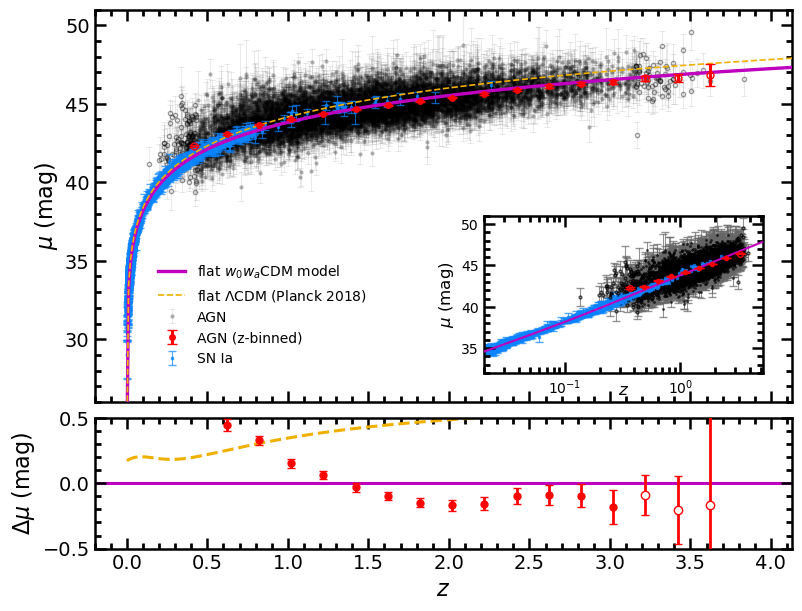

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4 (sorted by residual, largest last):
	z: 0.33 | object_id: 1414541 | npca_qso: N/A | SDSS: 013508.75+011450.0 | RA: 23.78646 | DEC: 1.24724 | Residual: 4.4
	z: 0.51 | object_id: 1450669 | npca_qso: N/A | SDSS: 231732.23+000346.5 | RA: 349.38430 | DEC: 0.06293 | Residual: 4.7
Residuals saved to plots/hubble/residuals.csv
Outliers (|residuals| > 5) saved to plots/hubble/outliers.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with mu_pred_std > 4:
	z: 0.51 | object_id: 1450669 | npca_qso: N/A | SDSS: 231732.23+000346.5 | RA: 349.38430 | DEC: 0.06293 | Residual: 4.7
	z: 0.33 | object_id: 1414541 | npca_qso: N/A | SDSS: 013508.75+011450.0 | RA: 23.78646 | DEC: 1.24724 | Residual: 4.4


(array([ 1.23589319, -0.35156886, -0.98402744, ...,  0.87081063,
         1.50912965,  0.18643129], shape=(8728,)),
 array([1.03918266, 1.17171197, 1.04127278, ..., 1.18330288, 1.00079294,
        0.99358095], shape=(8728,)),
 array([45.95655185, 46.42517926, 42.90532426, ..., 44.87479569,
        44.02862175, 44.76402595], shape=(8728,)),
 array([0.73670362, 0.91418848, 0.73964898, ..., 0.92899802, 0.6814823 ,
        0.67084628], shape=(8728,)),
 array([1.03918266, 1.17171197, 1.04127278, ..., 1.18330288, 1.00079294,
        0.99358095], shape=(8728,)))

In [ ]:
(
    flat_samples,
    model_labels,
    dm_interp,
    logZ,
    logZerr,
    debiased_residuals,
    age,
    age_err,
) = r

run_tag = hubble_fit.make_run_tag(
    cosmo_model="Flatw0waCDM",
    only_sna=False,
    speed="fast",      # match the value you used in run_single
    N=None,
    z_range=(0.44, 3.16),
)

hubble_fit.plot_hubble(
    flat_samples,
    df_agn,
    df_pantheon,
    cosmo_model="Flatw0waCDM",
    z_pivot_agn=hubble_fit.z_pivot_agn,
    show_true=False,
    show=True,
    debias=True,
    dm_interp=dm_interp,
    verbose=True,
)
